In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../datasets/Sleep_health_and_lifestyle_dataset.csv')
print(df.shape)
print(df.head())
print(df.columns.tolist())

(374, 13)
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80        

In [3]:
# Drop Person ID
df.drop('Person ID', axis=1, inplace=True)

# Split Blood Pressure into systolic and diastolic
df[['BP_Systolic', 'BP_Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df.drop('Blood Pressure', axis=1, inplace=True)

# Fill NaN in Sleep Disorder with 'None'
df['Sleep Disorder'].fillna('None', inplace=True)

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']:
    df[col] = le.fit_transform(df[col])

print(df.shape)
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

(374, 13)
   Gender  Age  Occupation  Sleep Duration  Quality of Sleep  \
0       1   27           9             6.1                 6   
1       1   28           1             6.2                 6   
2       1   28           1             6.2                 6   
3       1   28           6             5.9                 4   
4       1   28           6             5.9                 4   

   Physical Activity Level  Stress Level  BMI Category  Heart Rate  \
0                       42             6             3          77   
1                       60             8             0          75   
2                       60             8             0          75   
3                       30             8             2          85   
4                       30             8             2          85   

   Daily Steps  Sleep Disorder  BP_Systolic  BP_Diastolic  
0         4200               1          126            83  
1        10000               1          125            80  
2   

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1736\2836272859.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sleep Disorder'].fillna('None', inplace=True)


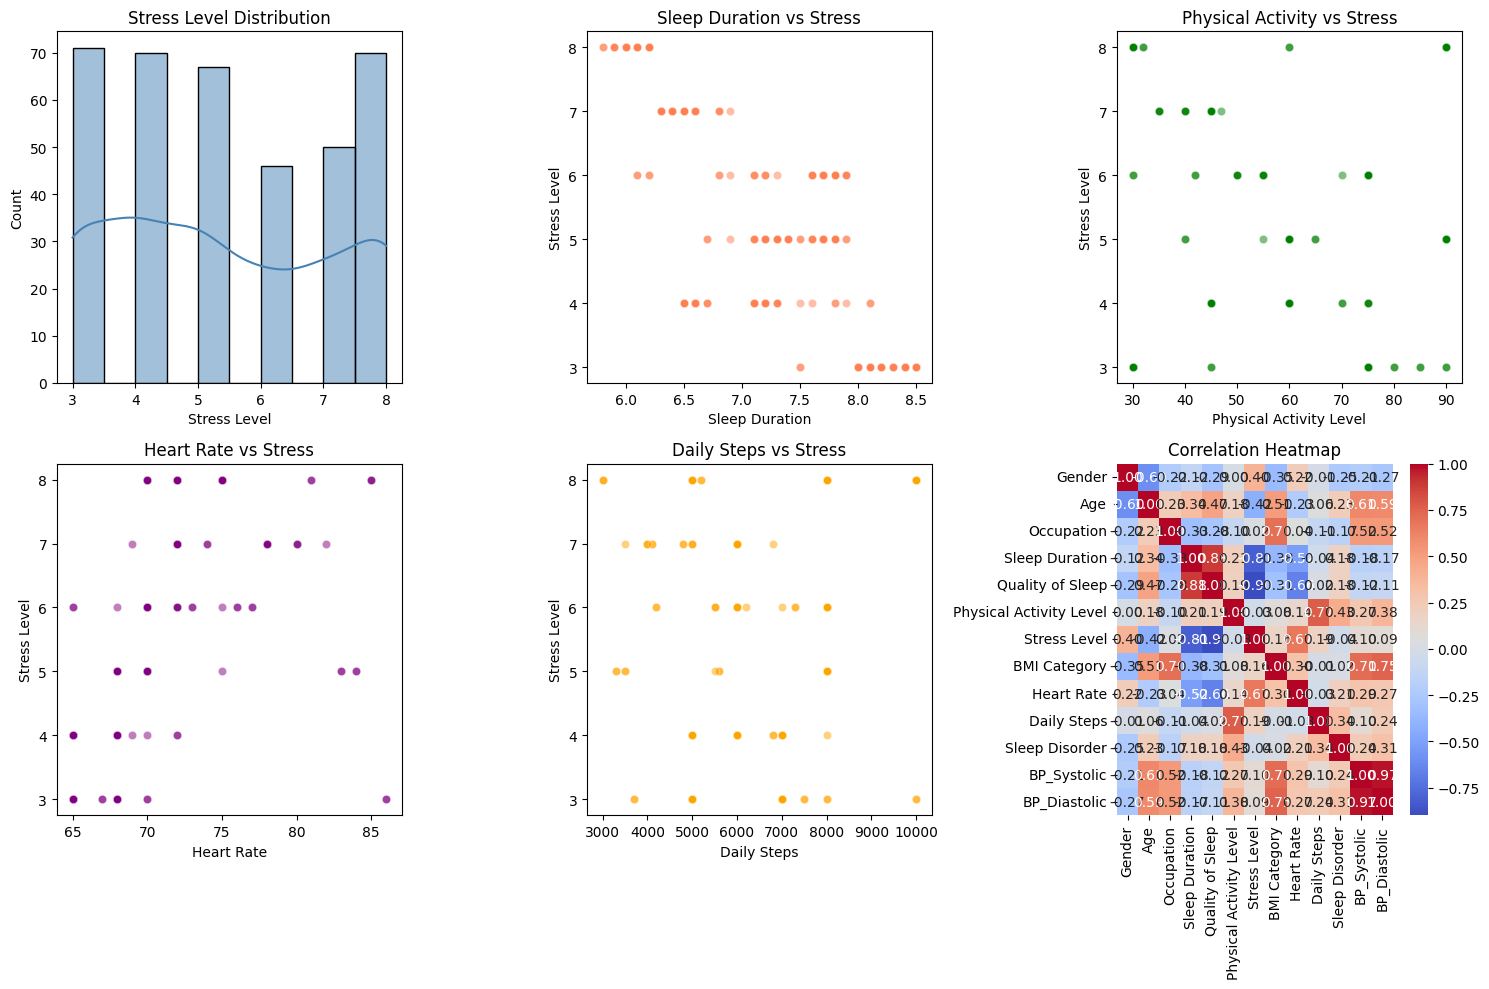

In [4]:
plt.figure(figsize=(15, 10))

# 1. Stress Level distribution
plt.subplot(2, 3, 1)
sns.histplot(df['Stress Level'], kde=True, color='steelblue')
plt.title('Stress Level Distribution')

# 2. Sleep Duration vs Stress
plt.subplot(2, 3, 2)
sns.scatterplot(x='Sleep Duration', y='Stress Level', data=df, color='coral', alpha=0.5)
plt.title('Sleep Duration vs Stress')

# 3. Physical Activity vs Stress
plt.subplot(2, 3, 3)
sns.scatterplot(x='Physical Activity Level', y='Stress Level', data=df, color='green', alpha=0.5)
plt.title('Physical Activity vs Stress')

# 4. Heart Rate vs Stress
plt.subplot(2, 3, 4)
sns.scatterplot(x='Heart Rate', y='Stress Level', data=df, color='purple', alpha=0.5)
plt.title('Heart Rate vs Stress')

# 5. Daily Steps vs Stress
plt.subplot(2, 3, 5)
sns.scatterplot(x='Daily Steps', y='Stress Level', data=df, color='orange', alpha=0.5)
plt.title('Daily Steps vs Stress')

# 6. Correlation heatmap
plt.subplot(2, 3, 6)
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('../notebooks/stress_eda.png', dpi=150)
plt.show()

In [5]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
import joblib

X = df.drop('Stress Level', axis=1)
y = df['Stress Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

best_model = None
best_r2 = 0

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name} → R²: {r2:.4f} | RMSE: {rmse:.4f}")
    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_name = name

print(f"\nBest model: {best_name} with R²: {best_r2:.4f}")

joblib.dump(best_model, '../models/stress_model.pkl')
print("Model saved!")

Linear Regression → R²: 0.9585 | RMSE: 0.3600
Random Forest → R²: 0.9902 | RMSE: 0.1753
XGBoost → R²: 0.9978 | RMSE: 0.0832

Best model: XGBoost with R²: 0.9978
Model saved!
